Copyright 2021 DeepMind Technologies Limited

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

     https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.

This colab showcases the usage of the Enformer model published in

**"Effective gene expression prediction from sequence by integrating long-range interactions"**

Žiga Avsec, Vikram Agarwal, Daniel Visentin, Joseph R. Ledsam, Agnieszka Grabska-Barwinska, Kyle R. Taylor, Yannis Assael, John Jumper, Pushmeet Kohli, David R. Kelley

**Note:** This colab will not yet work since the model isn't yet publicly available. We are working on enabling this and will update the colab accordingly.

### Steps

This colab demonstrates how to
- Make predictions with Enformer and reproduce Fig. 1d
- Compute contribution scores and reproduce parts of Fig. 2a
- Predict the effect of a genetic variant and reproduce parts of Fig. 3g
- Score multiple variants in a VCF 

## Setup

**Start the colab kernel with GPU**: Runtime -> Change runtime type -> GPU

In [ ]:
import tensorflow as tf
# Make sure the GPU is enabled 
assert tf.config.list_physical_devices('GPU'), 'Start the colab kernel with GPU: Runtime -> Change runtime type -> GPU'

2025-03-05 00:51:20.292818: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [2]:
#!pip install kipoiseq==0.5.2 --quiet > /dev/null
%pip install kipoiseq==0.5.2 --quiet > /dev/null
# You can ignore the pyYAML error

Note: you may need to restart the kernel to use updated packages.


### Imports

In [3]:
import tensorflow_hub as hub
import joblib
import gzip
import kipoiseq
from kipoiseq import Interval
import pyfaidx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os                                #new addition
import subprocess                        #new addition
from IPython.display import display      #new addition
import datetime                          #new addition
from pathlib import Path                 #new addition

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [4]:
#transform_path = 'gs://dm-enformer/models/enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl'
transform_path = '/lustre/scratch/mxwami/data/enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl'
model_path = 'https://tfhub.dev/deepmind/enformer/1'
fasta_file = '/lustre/scratch/mxwami/data/genome.fa'
#clinvar_vcf = '/data/projects/WAM_PC_ENFOR/MS_THESIS/ANACONDA/enformer/data/clinvar.vcf.gz'
clinvar_vcf_dir = '/lustre/scratch/mxwami/newdata3'
# Changes made in directories paths. 

In [5]:
# Download targets from Basenji2 dataset 
# Cite: Kelley et al Cross-species regulatory sequence activity prediction. PLoS Comput. Biol. 16, e1008050 (2020).
#targets_txt = 'https://raw.githubusercontent.com/calico/basenji/master/manuscripts/cross2020/targets_human.txt'
#df_targets = pd.read_csv(targets_txt, sep='\t')
#df_targets.head(3)
!wget https://raw.githubusercontent.com/calico/basenji/master/manuscripts/cross2020/targets_human.txt -O /lustre/scratch/mxwami/data/targets_human.txt
targets_txt = '/lustre/scratch/mxwami/data/targets_human.txt'
df_targets = pd.read_csv(targets_txt, sep='\t')
df_targets.head(3)

--2025-03-05 00:51:31--  https://raw.githubusercontent.com/calico/basenji/master/manuscripts/cross2020/targets_human.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 800919 (782K) [text/plain]
Saving to: ‘/lustre/scratch/mxwami/data/targets_human.txt’

100%[======================================>] 800,919     --.-K/s   in 0.02s   

2025-03-05 00:51:32 (49.1 MB/s) - ‘/lustre/scratch/mxwami/data/targets_human.txt’ saved [800919/800919]



,index,genome,identifier,file,clip,scale,sum_stat,description
0,0,0,ENCFF833POA,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:cerebellum male adult (27 years) and mal...
1,1,0,ENCFF110QGM,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:frontal cortex male adult (27 years) and...
2,2,0,ENCFF880MKD,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:chorion


In [6]:
# Filter and save prostate targets
prostate_targets = df_targets[df_targets['description'].str.contains('prostate', case=False)]
prostate_indices = prostate_targets.index.tolist()

# Save to file
prostate_file_path = '/lustre/scratch/mxwami/data/prostate_targets.txt'
prostate_targets.to_csv(prostate_file_path, sep='\t', index=False)

# Read the saved file
prostate_df_targets = pd.read_csv(prostate_file_path, sep='\t')
prostate_df_targets.head(3)

,index,genome,identifier,file,clip,scale,sum_stat,description
0,141,0,ENCFF739CBQ,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:epithelial cell of prostate
1,653,0,ENCFF069GRI,/home/drk/tillage/datasets/human/dnase/encode/...,32,2,mean,DNASE:prostate gland male adult (37 years)
2,1836,0,ENCFF278UPX,/home/drk/tillage/datasets/human/chip/encode/E...,32,2,mean,CHIP:POLR2A:prostate gland male adult (54 years)


### Download files

Download and index the reference genome fasta file

Credit to Genome Reference Consortium: https://www.ncbi.nlm.nih.gov/grc

Schneider et al 2017 http://dx.doi.org/10.1101/gr.213611.116: Evaluation of GRCh38 and de novo haploid genome assemblies demonstrates the enduring quality of the reference assembly

In [ ]:
!mkdir -p /lustre/scratch/mxwami/data
!wget -O - http://hgdownload.cse.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz | gunzip -c > {fasta_file}
pyfaidx.Faidx(fasta_file)
!ls /lustre/scratch/mxwami/data
# Changes made in directories paths. 

--2025-03-05 00:51:32--  http://hgdownload.cse.ucsc.edu/goldenPath/hg38/bigZips/hg38.fa.gz
Resolving hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)... 128.114.119.163
Connecting to hgdownload.cse.ucsc.edu (hgdownload.cse.ucsc.edu)|128.114.119.163|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 983659424 (938M) [application/x-gzip]
Saving to: ‘STDOUT’

100%[======================================>] 983,659,424 9.96MB/s   in 1m 43s 

2025-03-05 00:53:19 (9.11 MB/s) - written to stdout [983659424/983659424]

enformer.finetuned.SAD.robustscaler-PCA500-robustscaler.transform.pkl
genome.fa
genome.fa.fai
prostate_targets.txt
targets_human.txt


Download the clinvar file. Reference:

Landrum MJ, Lee JM, Benson M, Brown GR, Chao C, Chitipiralla S, Gu B, Hart J, Hoffman D, Jang W, Karapetyan K, Katz K, Liu C, Maddipatla Z, Malheiro A, McDaniel K, Ovetsky M, Riley G, Zhou G, Holmes JB, Kattman BL, Maglott DR. ClinVar: improving access to variant interpretations and supporting evidence. Nucleic Acids Res . 2018 Jan 4. PubMed PMID: 29165669 .


In [ ]:
#!wget https://ftp.ncbi.nlm.nih.gov/pub/clinvar/vcf_GRCh38/clinvar.vcf.gz -O /data/projects/WAM_PC_ENFOR/MS_THESIS/ANACONDA/enformer/data/clinvar.vcf.gz
# Changes made in directories paths and new data introduced. 
!wget https://quigleylab.s3.us-west-2.amazonaws.com/datasets/2018_04_15_WCDT_somatic_vcf.tar -O /lustre/scratch/mxwami/newdata3/clinvar.vcf.tar
os.system('tar -tf /lustre/scratch/mxwami/newdata3/clinvar.vcf.tar')
os.system('cd /lustre/scratch/mxwami/newdata3 && tar -xvf clinvar.vcf.tar --exclude=ABOUT_THESE_DATA && rm clinvar.vcf.tar')

--2025-03-05 00:53:52--  https://quigleylab.s3.us-west-2.amazonaws.com/datasets/2018_04_15_WCDT_somatic_vcf.tar
Resolving quigleylab.s3.us-west-2.amazonaws.com (quigleylab.s3.us-west-2.amazonaws.com)... 52.92.237.162, 3.5.78.206, 3.5.79.167, ...
Connecting to quigleylab.s3.us-west-2.amazonaws.com (quigleylab.s3.us-west-2.amazonaws.com)|52.92.237.162|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 78469120 (75M) [application/x-tar]
Saving to: ‘/lustre/scratch/mxwami/newdata3/clinvar.vcf.tar’

100%[======================================>] 78,469,120  5.50MB/s   in 14s    

2025-03-05 00:54:07 (5.22 MB/s) - ‘/lustre/scratch/mxwami/newdata3/clinvar.vcf.tar’ saved [78469120/78469120]

ABOUT_THESE_DATA
DTB-003-BL_somatic_pass_SNP.vcf.gz
DTB-005-BL_somatic_pass_SNP.vcf.gz
DTB-008-BL_somatic_pass_SNP.vcf.gz
DTB-009-BL_somatic_pass_SNP.vcf.gz
DTB-011-BL_somatic_pass_SNP.vcf.gz
DTB-018-BL_somatic_pass_SNP.vcf.gz
DTB-019-PRO_somatic_pass_SNP.vcf.gz
DTB-020-BL_somatic_pas

0

### Code (double click on the title to show the code)

In [9]:
# @title `Enformer`, `EnformerScoreVariantsNormalized`, `EnformerScoreVariantsPCANormalized`,
SEQUENCE_LENGTH = 393216

class Enformer:

  def __init__(self, tfhub_url):
    self._model = hub.load(tfhub_url).model

  def predict_on_batch(self, inputs):
    predictions = self._model.predict_on_batch(inputs)
    return {k: v.numpy() for k, v in predictions.items()}

  @tf.function
  def contribution_input_grad(self, input_sequence,
                              target_mask, output_head='human'):
    input_sequence = input_sequence[tf.newaxis]

    target_mask_mass = tf.reduce_sum(target_mask)
    with tf.GradientTape() as tape:
      tape.watch(input_sequence)
      prediction = tf.reduce_sum(
          target_mask[tf.newaxis] *
          self._model.predict_on_batch(input_sequence)[output_head]) / target_mask_mass

    input_grad = tape.gradient(prediction, input_sequence) * input_sequence
    input_grad = tf.squeeze(input_grad, axis=0)
    return tf.reduce_sum(input_grad, axis=-1)


class EnformerScoreVariantsRaw:

  def __init__(self, tfhub_url, organism='human'):
    self._model = Enformer(tfhub_url)
    self._organism = organism
  
  def predict_on_batch(self, inputs):
    ref_prediction = self._model.predict_on_batch(inputs['ref'])[self._organism]
    alt_prediction = self._model.predict_on_batch(inputs['alt'])[self._organism]

    return alt_prediction.mean(axis=1) - ref_prediction.mean(axis=1)


class EnformerScoreVariantsNormalized:

  def __init__(self, tfhub_url, transform_pkl_path,
               organism='human'):
    assert organism == 'human', 'Transforms only compatible with organism=human'
    self._model = EnformerScoreVariantsRaw(tfhub_url, organism)
    with tf.io.gfile.GFile(transform_pkl_path, 'rb') as f:
      transform_pipeline = joblib.load(f)
    self._transform = transform_pipeline.steps[0][1]  # StandardScaler.
    
  def predict_on_batch(self, inputs):
    scores = self._model.predict_on_batch(inputs)
    return self._transform.transform(scores)


class EnformerScoreVariantsPCANormalized:

  def __init__(self, tfhub_url, transform_pkl_path,
               organism='human', num_top_features=500):
    self._model = EnformerScoreVariantsRaw(tfhub_url, organism)
    with tf.io.gfile.GFile(transform_pkl_path, 'rb') as f:
      self._transform = joblib.load(f)
    self._num_top_features = num_top_features
    
  def predict_on_batch(self, inputs):
    scores = self._model.predict_on_batch(inputs)
    return self._transform.transform(scores)[:, :self._num_top_features]


# TODO(avsec): Add feature description: Either PCX, or full names.

In [10]:
# @title `variant_centered_sequences`

class FastaStringExtractor:
    
    def __init__(self, fasta_file):
        self.fasta = pyfaidx.Fasta(fasta_file)
        self._chromosome_sizes = {k: len(v) for k, v in self.fasta.items()}

    def extract(self, interval: Interval, **kwargs) -> str:
        # Truncate interval if it extends beyond the chromosome lengths.
        chromosome_length = self._chromosome_sizes[interval.chrom]
        desired_length = interval.end - interval.start
        trimmed_interval = Interval(interval.chrom,
                                    max(interval.start, 0),
                                    min(interval.end, chromosome_length),
                                    )
        # pyfaidx wants a 1-based interval
        sequence = str(self.fasta.get_seq(trimmed_interval.chrom,
                                          trimmed_interval.start + 1,
                                          trimmed_interval.stop).seq).upper()
        # Fill truncated values with N's.
        pad_upstream = 'N' * max(-interval.start, 0)
        pad_downstream = 'N' * max(interval.end - chromosome_length, 0)
        #return pad_upstream + sequence + pad_downstream
        final_sequence = pad_upstream + sequence + pad_downstream
    
        # Ensure exact length match
        if len(final_sequence) != desired_length:
            final_sequence = final_sequence[:desired_length]
    
        return final_sequence
        
    def close(self):
        return self.fasta.close()


def variant_generator(vcf_file, gzipped=False):
  """Yields a kipoiseq.dataclasses.Variant for each row in VCF file."""
  def _open(file):
    return gzip.open(vcf_file, 'rt') if gzipped else open(vcf_file)
    
  with _open(vcf_file) as f:
    for line in f:
      if line.startswith('#'):
        continue
      chrom, pos, id, ref, alt_list = line.split('\t')[:5]
      # Split ALT alleles and return individual variants as output.
      for alt in alt_list.split(','):
        yield kipoiseq.dataclasses.Variant(chrom=chrom, pos=pos,
                                           ref=ref, alt=alt, id=id)


def one_hot_encode(sequence):
  return kipoiseq.transforms.functional.one_hot_dna(sequence).astype(np.float32)


def variant_centered_sequences(vcf_file, sequence_length, gzipped=False,
                               chr_prefix=''):
  seq_extractor = kipoiseq.extractors.VariantSeqExtractor(
    reference_sequence=FastaStringExtractor(fasta_file))

  for variant in variant_generator(vcf_file, gzipped=gzipped):
    interval = Interval(chr_prefix + variant.chrom,
                        variant.pos, variant.pos)
    interval = interval.resize(sequence_length)
    center = interval.center() - interval.start

    reference = seq_extractor.extract(interval, [], anchor=center)
    alternate = seq_extractor.extract(interval, [variant], anchor=center)

    yield {'inputs': {'ref': one_hot_encode(reference),
                      'alt': one_hot_encode(alternate)},
           'metadata': {'chrom': chr_prefix + variant.chrom,
                        'pos': variant.pos,
                        'id': variant.id,
                        'ref': variant.ref,
                        'alt': variant.alt}}

In [11]:
# @title `plot_tracks`

def plot_tracks(tracks, interval, height=1.5):
  fig, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True)
  for ax, (title, y) in zip(axes, tracks.items()):
    ax.fill_between(np.linspace(interval.start, interval.end, num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(str(interval))
  plt.tight_layout()

## Make predictions for a genetic sequenece

In [12]:
model = Enformer(model_path)

fasta_extractor = FastaStringExtractor(fasta_file)

2025-03-05 00:54:09.106506: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /data/projects/WAM_PC_ENFOR/MS_THESIS/ANACONDA/Funseq2/FunSeq2/funseq2-1.0/Funseq2/vat/lib:
2025-03-05 00:54:09.106544: W tensorflow/stream_executor/cuda/cuda_driver.cc:326] failed call to cuInit: UNKNOWN ERROR (303)
2025-03-05 00:54:09.106577: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (narvi.cc.tut.fi): /proc/driver/nvidia/version does not exist
2025-03-05 00:54:09.107479: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flag

In [13]:
# @title Make predictions for an genomic example interval
target_interval = kipoiseq.Interval('chrX', 67_544_021, 67_730_619)  # @param

sequence_one_hot = one_hot_encode(fasta_extractor.extract(target_interval.resize(SEQUENCE_LENGTH)))
predictions = model.predict_on_batch(sequence_one_hot[np.newaxis])['human'][0]

2025-03-05 00:54:11.785826: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2025-03-05 00:54:11.985110: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2397265000 Hz


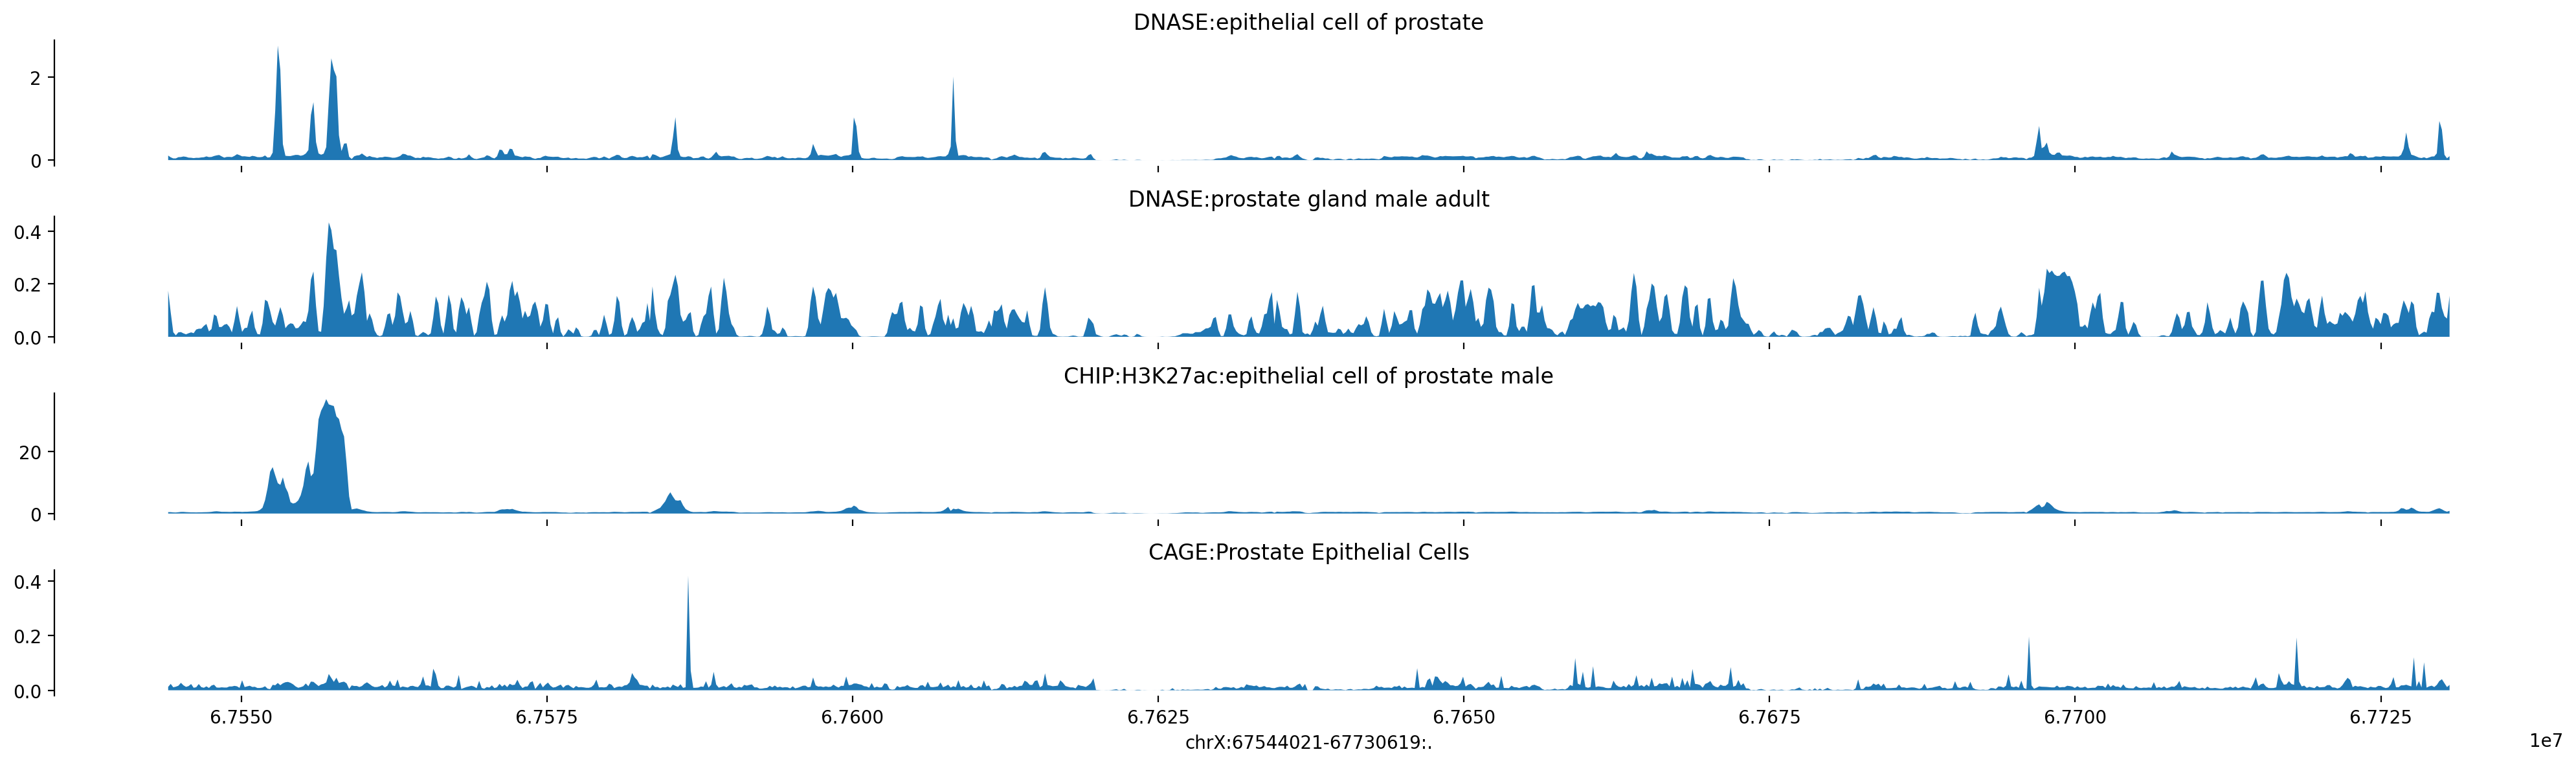

In [14]:
# @title Plot tracks
tracks = {'DNASE:epithelial cell of prostate': predictions[:, 141],
          'DNASE:prostate gland male adult': predictions[:, 653],
          'CHIP:H3K27ac:epithelial cell of prostate male': predictions[:, 4266],
          'CAGE:Prostate Epithelial Cells': np.log10(1 + predictions[:, 5071])}
plot_tracks(tracks, target_interval)

# Changes made in tracks.
#plt.savefig("output_plot.png")  # Save the generated plot
#plt.close()  # Close the plot to avoid memory issues in successive executions

## Contribution scores example

In [15]:
# @title Compute contribution scores
target_interval = kipoiseq.Interval('chr10', 87_862_638, 87_971_930)  # @param

sequence_one_hot = one_hot_encode(fasta_extractor.extract(target_interval.resize(SEQUENCE_LENGTH)))
predictions = model.predict_on_batch(sequence_one_hot[np.newaxis])['human'][0]

target_mask = np.zeros_like(predictions)
for idx in [447, 448, 449]:
  target_mask[idx, 4824] = 1
  target_mask[idx, 4838] = 1
# This will take some time since tf.function needs to get compiled.
contribution_scores = model.contribution_input_grad(sequence_one_hot.astype(np.float32), target_mask).numpy()
pooled_contribution_scores = tf.nn.avg_pool1d(np.abs(contribution_scores)[np.newaxis, :, np.newaxis], 128, 128, 'VALID')[0, :, 0].numpy()[1088:-1088]

2025-03-05 00:56:33.953789: W tensorflow/core/framework/cpu_allocator_impl.cc:80] Allocation of 1509949440 exceeds 10% of free system memory.


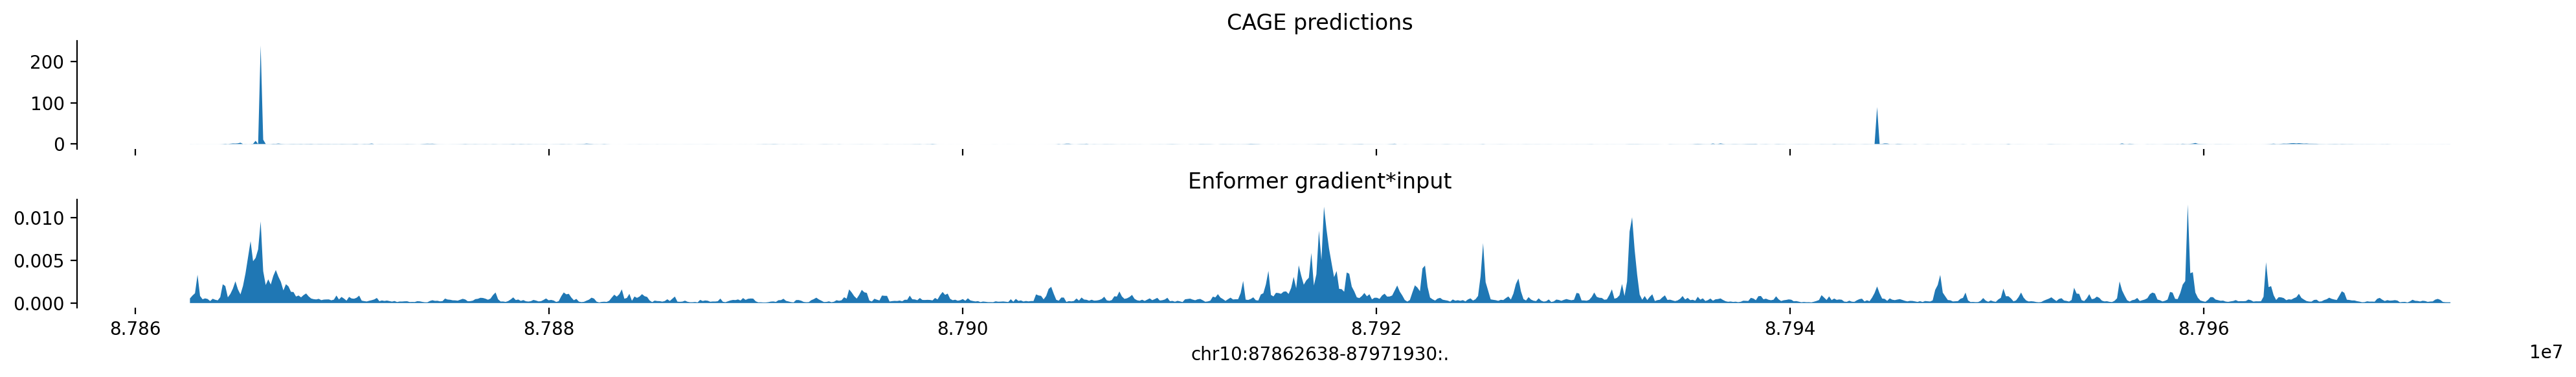

In [16]:
tracks = {'CAGE predictions': predictions[:, 4824],
          'Enformer gradient*input': np.minimum(pooled_contribution_scores, 0.03)}
plot_tracks(tracks, target_interval);

# Changes made in tracks.
#plt.savefig("output_plot2.png")  # Save the generated plot
#plt.close()  # Close the plot to avoid memory issues in successive executions

## Variant scoring example

In [17]:
'''# @title Score the variant
variant = kipoiseq.Variant('chrX', 66677894, 'C', 'T', id='rs141086308') # @param

# Center the interval at the variant
interval = kipoiseq.Interval(variant.chrom, variant.start, variant.start).resize(SEQUENCE_LENGTH)
seq_extractor = kipoiseq.extractors.VariantSeqExtractor(reference_sequence=fasta_extractor)
center = interval.center() - interval.start

reference = seq_extractor.extract(interval, [], anchor=center)
alternate = seq_extractor.extract(interval, [variant], anchor=center)

# Make predictions for the refernece and alternate allele
reference_prediction = model.predict_on_batch(one_hot_encode(reference)[np.newaxis])['human'][0]
alternate_prediction = model.predict_on_batch(one_hot_encode(alternate)[np.newaxis])['human'][0] '''

"# @title Score the variant\nvariant = kipoiseq.Variant('chrX', 66677894, 'C', 'T', id='rs141086308') # @param\n\n# Center the interval at the variant\ninterval = kipoiseq.Interval(variant.chrom, variant.start, variant.start).resize(SEQUENCE_LENGTH)\nseq_extractor = kipoiseq.extractors.VariantSeqExtractor(reference_sequence=fasta_extractor)\ncenter = interval.center() - interval.start\n\nreference = seq_extractor.extract(interval, [], anchor=center)\nalternate = seq_extractor.extract(interval, [variant], anchor=center)\n\n# Make predictions for the refernece and alternate allele\nreference_prediction = model.predict_on_batch(one_hot_encode(reference)[np.newaxis])['human'][0]\nalternate_prediction = model.predict_on_batch(one_hot_encode(alternate)[np.newaxis])['human'][0] "

In [18]:
'''# @title Visualize some tracks
variant_track = np.zeros_like(reference_prediction[:, 0], dtype=bool)
variant_track[variant_track.shape[0] // 2] = True
tracks = {'variant': variant_track,
          'CAGE/Prostate Epithelial Cells': reference_prediction[:, 5071],
          'CAGE/Prostate Epithelial Cells alt-ref': alternate_prediction[:, 5071] - reference_prediction[:, 5071],
          'CHIP:H3K27ac:epithelial cell of prostate male ref': reference_prediction[:, 4266],
          'CHIP:H3K27ac:epithelial cell of prostate male alt-ref': alternate_prediction[:, 4266] - reference_prediction[:, 4266],
          'DNASE/Prostate Epithelial Cells ref': reference_prediction[:, 141],
          'DNASE/Prostate Epithelial Cells alt-ref': alternate_prediction[:, 141] - reference_prediction[:, 141],
          'CAGE/prostate cancer cell line:PC-3 ref': reference_prediction[:, 4824],
          'CAGE/prostate cancer cell line:PC-3 alt-ref': alternate_prediction[:, 4824] - reference_prediction[:, 4824], 
          'CAGE/prostate cancer cell line:DU145 ref': reference_prediction[:, 4838],
          'CAGE/prostate cancer cell line:DU145 alt-ref': alternate_prediction[:, 4838] - reference_prediction[:, 4838],
          }

plot_tracks(tracks, interval.resize(reference_prediction.shape[0] * 128), height=1)

# Changes made in tracks.
#plt.savefig("output_plot3.png")  # Save the generated plot
#plt.close()  # Close the plot to avoid memory issues in successive executions'''

'# @title Visualize some tracks\nvariant_track = np.zeros_like(reference_prediction[:, 0], dtype=bool)\nvariant_track[variant_track.shape[0] // 2] = True\ntracks = {\'variant\': variant_track,\n          \'CAGE/Prostate Epithelial Cells\': reference_prediction[:, 5071],\n          \'CAGE/Prostate Epithelial Cells alt-ref\': alternate_prediction[:, 5071] - reference_prediction[:, 5071],\n          \'CHIP:H3K27ac:epithelial cell of prostate male ref\': reference_prediction[:, 4266],\n          \'CHIP:H3K27ac:epithelial cell of prostate male alt-ref\': alternate_prediction[:, 4266] - reference_prediction[:, 4266],\n          \'DNASE/Prostate Epithelial Cells ref\': reference_prediction[:, 141],\n          \'DNASE/Prostate Epithelial Cells alt-ref\': alternate_prediction[:, 141] - reference_prediction[:, 141],\n          \'CAGE/prostate cancer cell line:PC-3 ref\': reference_prediction[:, 4824],\n          \'CAGE/prostate cancer cell line:PC-3 alt-ref\': alternate_prediction[:, 4824] - ref

In [ ]:

# Code modifications and define directories for noncoding variants.
input_dir = '/lustre/scratch/mxwami/SNPEF_GENE/noncoding_variants'
output_base_dir = '/lustre/scratch/mxwami/FILE5NONCODINGVISUALIZATIONS/ENFORMERNONCODING'

def process_vcf_file(vcf_path, gene_name):
    # Create output directory for gene
    output_dir = os.path.join(output_base_dir, gene_name)
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Process each variant in the VCF file
    for variant in variant_generator(vcf_path):
        # Center the interval at the variant
        interval = kipoiseq.Interval(variant.chrom, variant.start, variant.start).resize(SEQUENCE_LENGTH)
        
        # Extract sequences
        seq_extractor = kipoiseq.extractors.VariantSeqExtractor(reference_sequence=fasta_extractor)
        center = interval.center() - interval.start
        reference = seq_extractor.extract(interval, [], anchor=center)
        alternate = seq_extractor.extract(interval, [variant], anchor=center)
        
        # Make predictions
        reference_prediction = model.predict_on_batch(one_hot_encode(reference)[np.newaxis])['human'][0]
        alternate_prediction = model.predict_on_batch(one_hot_encode(alternate)[np.newaxis])['human'][0]
        
        # Create visualization
        variant_track = np.zeros_like(reference_prediction[:, 0], dtype=bool)
        variant_track[variant_track.shape[0] // 2] = True

        tracks = {
            'variant': variant_track,
            'CAGE/Prostate Epithelial Cells ref': reference_prediction[:, 5071],
            'CAGE/Prostate Epithelial Cells alt-ref': alternate_prediction[:, 5071] - reference_prediction[:, 5071],
           # 'CAGE/prostate, adult, pool1 ref': reference_prediction[:, 4690],
           # 'CAGE/prostate, adult, pool1 alt-ref': alternate_prediction[:, 4690] - reference_prediction[:, 4690],
           # 'CAGE/Prostate Epithelial Cells (polarized) ref': reference_prediction[:, 4785],
           # 'CAGE/Prostate Epithelial Cells (polarized) alt-ref': alternate_prediction[:, 4785] - reference_prediction[:, 4785],
           # 'CAGE/Prostate Stromal Cells ref': reference_prediction[:, 4786],
           # 'CAGE/Prostate Stromal Cells alt-ref': alternate_prediction[:, 4786] - reference_prediction[:, 4786],
           # 'CAGE/prostate cancer cell line:PC-3 ref': reference_prediction[:, 4824],
           # 'CAGE/prostate cancer cell line:PC-3 alt-ref': alternate_prediction[:, 4824] - reference_prediction[:, 4824],
           # 'CAGE/prostate cancer cell line:DU145 ref': reference_prediction[:, 4838],
           # 'CAGE/prostate cancer cell line:DU145 alt-ref': alternate_prediction[:, 4838] - reference_prediction[:, 4838],
           # 'CAGE/Smooth Muscle Cells - Prostate ref': reference_prediction[:, 5055],
           # 'CAGE/Smooth Muscle Cells - Prostate alt-ref': alternate_prediction[:, 5055] - reference_prediction[:, 5055],
        }
        
        plot_tracks(tracks, interval.resize(reference_prediction.shape[0] * 128), height=1)
        
        # Save plot with gene name and position
        output_file = os.path.join(output_dir, f"{gene_name}_POS_{variant.pos}.png")
        plt.savefig(output_file)
        plt.close()

def main():
    # Process all files
    vcf_files = sorted([f for f in os.listdir(input_dir) if f.endswith('_noncoding_variants.vcf')])
    
    for vcf_file in vcf_files:
        gene_name = vcf_file.split('_noncoding_variants.vcf')[0]
        vcf_path = os.path.join(input_dir, vcf_file)
        process_vcf_file(vcf_path, gene_name)
        print(f"Processed {gene_name}")

if __name__ == "__main__":
    main()

In [ ]:

# Code modifications and define directories for coding variants.
input_dir = '/lustre/scratch/mxwami/SNPEF_GENE/missense_variants'
output_base_dir = '/lustre/scratch/mxwami/FILE4CODINGVISULIZATIONS/ENFORMER_MISSENSE'

def process_vcf_file(vcf_path, gene_name):
    # Create output directory for gene
    output_dir = os.path.join(output_base_dir, gene_name)
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Process each variant in the VCF file
    for variant in variant_generator(vcf_path):
        # Center the interval at the variant
        interval = kipoiseq.Interval(variant.chrom, variant.start, variant.start).resize(SEQUENCE_LENGTH)
        
        # Extract sequences
        seq_extractor = kipoiseq.extractors.VariantSeqExtractor(reference_sequence=fasta_extractor)
        center = interval.center() - interval.start
        reference = seq_extractor.extract(interval, [], anchor=center)
        alternate = seq_extractor.extract(interval, [variant], anchor=center)
        
        # Make predictions
        reference_prediction = model.predict_on_batch(one_hot_encode(reference)[np.newaxis])['human'][0]
        alternate_prediction = model.predict_on_batch(one_hot_encode(alternate)[np.newaxis])['human'][0]
        
        # Create visualization
        variant_track = np.zeros_like(reference_prediction[:, 0], dtype=bool)
        variant_track[variant_track.shape[0] // 2] = True
        
        tracks = {
            'variant': variant_track,
            'CAGE/Prostate Epithelial Cells ref': reference_prediction[:, 5071],
            'CAGE/Prostate Epithelial Cells alt-ref': alternate_prediction[:, 5071] - reference_prediction[:, 5071],
           # 'CAGE/prostate, adult, pool1 ref': reference_prediction[:, 4690],
           # 'CAGE/prostate, adult, pool1 alt-ref': alternate_prediction[:, 4690] - reference_prediction[:, 4690],
           # 'CAGE/Prostate Epithelial Cells (polarized) ref': reference_prediction[:, 4785],
           # 'CAGE/Prostate Epithelial Cells (polarized) alt-ref': alternate_prediction[:, 4785] - reference_prediction[:, 4785],
           # 'CAGE/Prostate Stromal Cells ref': reference_prediction[:, 4786],
           # 'CAGE/Prostate Stromal Cells alt-ref': alternate_prediction[:, 4786] - reference_prediction[:, 4786],
           # 'CAGE/prostate cancer cell line:PC-3 ref': reference_prediction[:, 4824],
           # 'CAGE/prostate cancer cell line:PC-3 alt-ref': alternate_prediction[:, 4824] - reference_prediction[:, 4824],
           # 'CAGE/prostate cancer cell line:DU145 ref': reference_prediction[:, 4838],
           # 'CAGE/prostate cancer cell line:DU145 alt-ref': alternate_prediction[:, 4838] - reference_prediction[:, 4838],
           # 'CAGE/Smooth Muscle Cells - Prostate ref': reference_prediction[:, 5055],
           # 'CAGE/Smooth Muscle Cells - Prostate alt-ref': alternate_prediction[:, 5055] - reference_prediction[:, 5055],
        }
        
        plot_tracks(tracks, interval.resize(reference_prediction.shape[0] * 128), height=1)
        
        # Save plot with gene name and position
        output_file = os.path.join(output_dir, f"{gene_name}_POS_{variant.pos}.png")
        plt.savefig(output_file)
        plt.close()

def main():
    # Process first two files as trial
    vcf_files = sorted([f for f in os.listdir(input_dir) if f.endswith('_missense_variants.vcf')])
    
    for vcf_file in vcf_files:
        gene_name = vcf_file.split('_missense_variants.vcf')[0]
        vcf_path = os.path.join(input_dir, vcf_file)
        process_vcf_file(vcf_path, gene_name)
        print(f"Processed {gene_name}")

if __name__ == "__main__":
    main()

Processed AKT1
Processed APC


## Score variants in a VCF file

### Report top 20 PCs

In [ ]:
enformer_score_variants = EnformerScoreVariantsPCANormalized(model_path, transform_path, num_top_features=20)

In [ ]:
# Score the first 5 variants from ClinVar
# Lower-dimensional scores (20 PCs)

'''it = variant_centered_sequences(clinvar_vcf, sequence_length=SEQUENCE_LENGTH,
                                gzipped=True, chr_prefix='chr')'''

'''it = variant_centered_sequences(clinvar_vcf, sequence_length=SEQUENCE_LENGTH,
                                gzipped=True, chr_prefix='')
example_list = []
for i, example in enumerate(it):
  if i >= 5:
    break
  variant_scores = enformer_score_variants.predict_on_batch(
      {k: v[tf.newaxis] for k,v in example['inputs'].items()})[0]
  variant_scores = {f'PC{i}': score for i, score in enumerate(variant_scores)}
  example_list.append({**example['metadata'],
                       **variant_scores})
  if i % 2 == 0:
    print(f'Done {i}')
df = pd.DataFrame(example_list)
df

# Changes made
#print(df.to_string())'''

### Report all 5,313 features (z-score normalized)

In [ ]:
enformer_score_variants_all = EnformerScoreVariantsNormalized(model_path, transform_path)

In [ ]:
# Score the first 5 variants from ClinVar
# All Scores

'''
it = variant_centered_sequences(clinvar_vcf, sequence_length=SEQUENCE_LENGTH,
                                gzipped=True, chr_prefix='chr')

it = variant_centered_sequences(clinvar_vcf, sequence_length=SEQUENCE_LENGTH,
                                gzipped=True, chr_prefix='')
example_list = []
for i, example in enumerate(it):
  if i >= 5:
    break
  variant_scores = enformer_score_variants_all.predict_on_batch(
      {k: v[tf.newaxis] for k,v in example['inputs'].items()})[0]
  variant_scores = variant_scores[prostate_indices]  
  variant_scores = {f'{i}_{name[:20]}': score for i, (name, score) in enumerate(zip(prostate_df_targets.description, variant_scores))}
  example_list.append({**example['metadata'],
                       **variant_scores})
  if i % 2 == 0:
    print(f'Done {i}')
df = pd.DataFrame(example_list)
df

# Changes made
#print(df.to_string())'''

In [ ]:
# Main Code
# Addition + Modifications in existing code
OUTPUT_DIR = '/lustre/scratch/mxwami/4_Modified_3_Sorted_3_Ascending_Order/new/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def count_variants(vcf_file):
    cmd = f"zcat {vcf_file} | grep -v '^#' | wc -l"
    result = subprocess.check_output(cmd, shell=True)
    return int(result.decode().strip())

# Collect and sort files by variant count
vcf_files = []
for vcf_file in os.listdir(clinvar_vcf_dir):
    if vcf_file.endswith('_SNP.vcf.gz'):
        full_path = os.path.join(clinvar_vcf_dir, vcf_file)
        variant_count = count_variants(full_path)
        vcf_files.append((vcf_file, variant_count))
        print(f"{vcf_file}: {variant_count} variants")

# Sort files by variant count (smallest to largest)
sorted_files = sorted(vcf_files, key=lambda x: x[1])

print("\nFiles sorted by variant count (ascending):")
for file, count in sorted_files:
    print(f"{file}: {count} variants")

example_list = []
total_variants_all_files = 0
total_processed_variants = 0

# Process all files in ascending order
for vcf_file, total_variants in sorted_files[70:92]:
    clinvar_vcf = os.path.join(clinvar_vcf_dir, vcf_file)
    file_name = vcf_file.split('_SNP.vcf.gz')[0]
    output_vcf = os.path.join(OUTPUT_DIR, f'{file_name}_variants.vcf')
    
    print(f"\nProcessing: {vcf_file}")
    print(f"Total variants: {total_variants}")
    
    with open(output_vcf, 'w') as f:
        f.write('##fileformat=VCFv4.2\n')
    
    it = variant_centered_sequences(clinvar_vcf, sequence_length=SEQUENCE_LENGTH,
                                gzipped=True, chr_prefix='')
    
    for i, example in enumerate(it):
        variant_scores = enformer_score_variants_all.predict_on_batch(
            {k: v[tf.newaxis] for k,v in example['inputs'].items()})[0]
        
        prostate_scores = {f'{i}_{name[:20]}': float(score) 
                      for i, (name, score) in enumerate(zip(df_targets.description, variant_scores))
                      if 'prostate' in name.lower()}
        
        example_list.append({**example['metadata'], 'file_name': file_name, **prostate_scores})
        
        if i == 0:
            with open(output_vcf, 'a') as f:
                headers = ['#CHROM', 'POS', 'ID', 'REF', 'ALT'] + list(prostate_scores.keys())
                f.write('\t'.join(headers) + '\n')
        
        basic_info = [
            example['metadata']['chrom'],
            str(example['metadata']['pos']),
            example['metadata']['id'],
            example['metadata']['ref'],
            example['metadata']['alt']
        ]
        scores = [f"{score:.6f}" for score in prostate_scores.values()]
        
        with open(output_vcf, 'a') as f:
            f.write('\t'.join(basic_info + scores) + '\n')
        
        if i % 1000 == 0:
            print(f'{file_name}: Done {i}')
        
        total_processed_variants += 1
    
    total_variants_all_files += total_variants
    print(f"Completed {file_name}: {i+1}/{total_variants} variants")

df_prostate = pd.DataFrame(example_list)
display(df_prostate)

print("\nFinal Statistics:")
print(f"Total variants across all files: {total_variants_all_files}")
print(f"Total processed variants: {total_processed_variants}")
print(f"Processing rate: {(total_processed_variants/total_variants_all_files)*100:.2f}%")

# Create log file with timestamp
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
log_file = os.path.join(OUTPUT_DIR, f'processing_log_{timestamp}.txt')

# Write processing results to log file
with open(log_file, 'w') as f:
    f.write("Processing Summary\n")
    f.write("=================\n\n")
    
    f.write("Files processed in ascending order of variant count:\n")
    for file, count in sorted_files:
        f.write(f"{file}: {count} variants\n")
    
    f.write("\nFinal Statistics:\n")
    f.write(f"Total variants across all files: {total_variants_all_files}\n")
    f.write(f"Total processed variants: {total_processed_variants}\n")
    f.write(f"Processing rate: {(total_processed_variants/total_variants_all_files)*100:.2f}%\n")

print(f"\nLog file created: {log_file}")

In [ ]:
# Save to Excel with and without index
df_prostate.to_excel('/lustre/scratch/mxwami/4_Modified_3_Sorted_3_Ascending_Order/new/all_clinvar4_prostate_idx_True.xlsx', index=True)
df_prostate.to_excel('/lustre/scratch/mxwami/4_Modified_3_Sorted_3_Ascending_Order/new/all_clinvar4_prostate_idx_False.xlsx', index=False)

# Save to VCF
vcf_output = '/lustre/scratch/mxwami/4_Modified_3_Sorted_3_Ascending_Order/new/all_clinvar4_prostate.vcf'

# Get score columns (all columns except metadata)
score_columns = [col for col in df_prostate.columns if col not in ['chrom', 'pos', 'id', 'ref', 'alt', 'file_name']]

# Create header
vcf_header = '##fileformat=VCFv4.2\n'
vcf_header += '#CHROM\tPOS\tID\tREF\tALT\tFILE_NAME\t' + '\t'.join(score_columns) + '\n'

with open(vcf_output, 'w') as f:
    f.write(vcf_header)
    for _, row in df_prostate.iterrows():
        basic_info = f"{row['chrom']}\t{row['pos']}\t{row['id']}\t{row['ref']}\t{row['alt']}\t{row['file_name']}"
        scores = '\t'.join([f"{row[col]:.6f}" for col in score_columns])
        vcf_line = f"{basic_info}\t{scores}\n"
        f.write(vcf_line)